### OpenAI Whisper -> CNN -> Transformer -> Fully Connected -> Output

Goal is to try and replicate the architecture of OpenAI Whisper using a CNN and Transformer. Reference off the Automatic Speech Disfluency Detection Using wav2vec2.0 for Different Languages with Variable Lengths paper.

**Modified for single classification of Block features only.**

In [1]:
import pandas as pd
import torch
import librosa
import os
from transformers import WhisperFeatureExtractor, WhisperModel
from tqdm.notebook import tqdm # visualization
import numpy as np 
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader # for training
from sklearn.utils.class_weight import compute_class_weight # class weights
from sklearn.model_selection import train_test_split # split data
from sklearn.preprocessing import LabelEncoder #transform labels
import matplotlib.pyplot as plt # visualization
import seaborn as sns # visualization
from sklearn.metrics import confusion_matrix, classification_report # visualization
import copy # copy and save model 
import math
import gc

In [2]:
df = pd.read_csv('../archive/Training/SEP-28k-Extended_clips.csv')

# represent types of disfluency
disfluency_cols = ['Block', 'Prolongation', 'SoundRep', 'WordRep', 'Interjection'] # keep all labels to prevent fluent sample pollution

# Filter the dataframe for Blocks (exactly 3 votes) only
blocks_df = df[df['Block'] == 3].copy()
blocks_df['target_label'] = 'Block'

# Filter the dataframe for Flunent votes 0
fluent_df = df[df[disfluency_cols].eq(0).all(axis=1)].copy()

# Sample fluent data to keep 50-50 ratio
print(f"Total Block samples: {len(blocks_df)}")
print(f"Total Fluent samples before sampling: {len(fluent_df)}")

# Keep the fluent data proportional with the block
# around 50/50 balance. 
if len(fluent_df) >= len(blocks_df):
    fluent_sampled_df = fluent_df.sample(n=len(blocks_df), random_state=42).copy()
else:
    
    fluent_sampled_df = fluent_df.copy()

fluent_sampled_df['target_label'] = 'Fluent'

# Combine dataframes
absolute_labels_df = pd.concat([blocks_df, fluent_sampled_df], ignore_index=True)

# path
absolute_labels_df['audio_path'] = (
    'SEP-28k_CLIP/' + 
    absolute_labels_df['Show'] + '/' + 
    absolute_labels_df['EpId'].astype(str) + '/' + 
    absolute_labels_df['Show'] + '_' + 
    absolute_labels_df['EpId'].astype(str) + '_' + 
    absolute_labels_df['ClipId'].astype(str) + '.wav'
)

print(f"Combined rows (balanced): {len(absolute_labels_df)}\n")
print(absolute_labels_df['target_label'].value_counts())
print("\n")
print(absolute_labels_df[['audio_path', 'target_label', 'Block']].head())


Total Block samples: 528
Total Fluent samples before sampling: 6004
Combined rows (balanced): 1056

target_label
Block     528
Fluent    528
Name: count, dtype: int64


                                       audio_path target_label  Block
0   SEP-28k_CLIP/HeStutters/1/HeStutters_1_62.wav        Block      3
1   SEP-28k_CLIP/HeStutters/1/HeStutters_1_75.wav        Block      3
2  SEP-28k_CLIP/HeStutters/1/HeStutters_1_106.wav        Block      3
3  SEP-28k_CLIP/HeStutters/1/HeStutters_1_133.wav        Block      3
4  SEP-28k_CLIP/HeStutters/1/HeStutters_1_170.wav        Block      3


In [5]:
df = absolute_labels_df.copy() 

# clean the IDs ex: '0.0' become '0'
df['EpId_clean'] = df['EpId'].astype(float).astype(int).astype(str)
df['ClipId_clean'] = df['ClipId'].astype(float).astype(int).astype(str)

# file path (../SEP-28k_CLIP) 
df['audio_path'] = (
    "../SEP-28k_CLIP/" + 
    df['Show'].astype(str) + "/" + 
    df['EpId_clean'] + "/" + 
    df['Show'].astype(str) + "_" + 
    df['EpId_clean'] + "_" + 
    df['ClipId_clean'] + ".wav"
)

# check for file path
test_path = df['audio_path'].iloc[0]
print(f"🔍 Checking first file at: {os.path.abspath(test_path)}")
if not os.path.exists(test_path):
    print("❌ ERROR: File STILL not found! Please stop and double-check your folder structure.")
else:
    print("✅ File found! Pathing is correct.\n")

# Set up the Whisper Model
model_name = "openai/whisper-base"
feature_extractor = WhisperFeatureExtractor.from_pretrained(model_name)
model = WhisperModel.from_pretrained(model_name)

# find Mac GPU, also allowed for NVIDIA GPU
if torch.backends.mps.is_available():
    device = "mps"
    print("Using Mac GPU (MPS) for acceleration!")
elif torch.cuda.is_available():
    device = "cuda"
    print("Using NVIDIA GPU (CUDA) for acceleration!")
else:
    device = "cpu"
    print("Using CPU. (No GPU detected)")

model.to(device)

def get_whisper_embedding_sequence(audio_path):
    if not os.path.exists(audio_path): return None
    try:
        # Load audio at 16k Hz
        speech_array, sampling_rate = librosa.load(audio_path, sr=16000)
        inputs = feature_extractor(speech_array, sampling_rate=16000, return_tensors="pt")
        input_features = inputs.input_features.to(device)
        
        with torch.no_grad():
            encoder_outputs = model.encoder(input_features)
            
        # remove squeeze dimension
        embedding = encoder_outputs.last_hidden_state.squeeze(0).cpu().numpy()
        return embedding 
    except Exception as e:
        print(f"Error: {e}")
        return None

# Process the files
print(f"Processing audio files into sequences...")
all_embeddings = []
valid_indices = []

for idx, path in tqdm(enumerate(df['audio_path']), total=len(df)):
    emb = get_whisper_embedding_sequence(path) 
    
    if emb is not None:
        all_embeddings.append(emb)
        valid_indices.append(idx)

# Save as a true 3D Numpy Array
# (Samples, 150, 512)
np.save('whisper_embeddings_block.npy', np.array(all_embeddings))


clean_df = df.iloc[valid_indices].copy()
clean_df.to_csv('SEP-28k_block_paths.csv', index=False)
print(f"🎉 Finished! Shape saved: {np.array(all_embeddings).shape}")

🔍 Checking first file at: /Users/jaskirtkaler/Github Repo/disfluency_detection/SEP-28k_CLIP/HeStutters/1/HeStutters_1_62.wav
✅ File found! Pathing is correct.



Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

Using Mac GPU (MPS) for acceleration!
Processing audio files into sequences...


  0%|          | 0/1056 [00:00<?, ?it/s]

🎉 Finished! Shape saved: (1056, 1500, 512)


### MODEL


In [6]:
print("Loading data...")
X_raw = np.load('whisper_embeddings_block.npy') 

# Slice to 3 seconds (150 tokens) to remove 1,350 tokens of silence
# "memory footprint" from 12GB to ~1.2GB I had AI help me with this
X = X_raw[:, :150, :] 

# Free up the old memory immediately
print(f"Original Shape: {X_raw.shape} | Optimized Shape: {X.shape}")
del X_raw
gc.collect() 

df = pd.read_csv('SEP-28k_block_paths.csv')
y_text = df['target_label'].values

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_text)
num_classes = len(label_encoder.classes_)

# Split off 20% for Test, then 25% of 80% for Val
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

# Convert to Tensors (Directly onto CPU first, then DataLoaders handle device move)
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=32, shuffle=False)

print(f"🎉 Memory Cleaned. Data Splits -> Train: {len(X_train)} | Val: {len(X_val)}")

# Cnn + transformer

class TemporalCNNEncoder(nn.Module):
    def __init__(self):
        super(TemporalCNNEncoder, self).__init__()
        # Whisper base dim is 512. We treat these as "Channels" for the CNN
        self.conv1 = nn.Conv1d(in_channels=512, out_channels=256, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(256)
        self.conv2 = nn.Conv1d(in_channels=256, out_channels=128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(128)
        self.relu = nn.GELU()
        self.pool = nn.MaxPool1d(kernel_size=2) 

    def forward(self, x):
        # x enters as [Batch, 150, 512]. Conv1d: [Batch, Channels, Time]
        x = x.transpose(1, 2) 
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        return x.transpose(1, 2) # Returns [Batch, 75, 128] for Transformer

class TransformerBrain(nn.Module):
    def __init__(self, num_classes, d_model=128, seq_length=75):
        super(TransformerBrain, self).__init__()
        self.pos_embedding = nn.Parameter(torch.randn(1, seq_length, d_model) * 0.01)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=8, dim_feedforward=512, dropout=0.3, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=3)
        self.fc = nn.Linear(d_model, num_classes)

    def forward(self, x):
        x = x + self.pos_embedding
        x = self.transformer(x)
        x = x.mean(dim=1) 
        return self.fc(x)

class EndToEndStutterModel(nn.Module):
    def __init__(self, num_classes):
        super(EndToEndStutterModel, self).__init__()
        self.cnn = TemporalCNNEncoder()
        self.transformer = TransformerBrain(num_classes)

    def forward(self, x):
        return self.transformer(self.cnn(x))


# training and weights 
device = "mps" if torch.backends.mps.is_available() else "cpu"

class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

model = EndToEndStutterModel(num_classes).to(device)
criterion = nn.CrossEntropyLoss(weight=weights_tensor)
optimizer = optim.AdamW(model.parameters(), lr=0.0005, weight_decay=1e-4)

epochs = 100
patience = 15
best_val_loss = float('inf')
patience_counter = 0
best_model_weights = copy.deepcopy(model.state_dict())


# training 
print(f"Starting training on {device}...")

for epoch in range(epochs):
    model.train()
    running_train_loss = 0.0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item()
        
    model.eval()
    running_val_loss, correct_val, total_val = 0.0, 0, 0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            running_val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_val += batch_y.size(0)
            correct_val += (predicted == batch_y).sum().item()
            
    avg_val_loss = running_val_loss / len(val_loader)
    val_acc = 100 * correct_val / total_val
    print(f"Epoch {epoch+1:02d} | Train Loss: {running_train_loss/len(train_loader):.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        best_model_weights = copy.deepcopy(model.state_dict())
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\n🛑 Early stopping triggered at Epoch {epoch+1}!")
            model.load_state_dict(best_model_weights)
            break
 
print("\n🎉 Training complete!")

Loading data...
Original Shape: (1056, 1500, 512) | Optimized Shape: (1056, 150, 512)
🎉 Memory Cleaned. Data Splits -> Train: 633 | Val: 211
Starting training on mps...
Epoch 01 | Train Loss: 0.4667 | Val Loss: 0.5329 | Val Acc: 77.73%
Epoch 02 | Train Loss: 0.2680 | Val Loss: 0.4044 | Val Acc: 82.94%
Epoch 03 | Train Loss: 0.1530 | Val Loss: 0.3714 | Val Acc: 84.83%
Epoch 04 | Train Loss: 0.1345 | Val Loss: 0.4921 | Val Acc: 81.52%
Epoch 05 | Train Loss: 0.1160 | Val Loss: 0.5743 | Val Acc: 84.83%
Epoch 06 | Train Loss: 0.0686 | Val Loss: 0.4824 | Val Acc: 86.26%
Epoch 07 | Train Loss: 0.0634 | Val Loss: 0.4795 | Val Acc: 87.20%
Epoch 08 | Train Loss: 0.0313 | Val Loss: 0.6320 | Val Acc: 87.20%
Epoch 09 | Train Loss: 0.0315 | Val Loss: 0.6600 | Val Acc: 86.26%
Epoch 10 | Train Loss: 0.0437 | Val Loss: 0.5698 | Val Acc: 86.73%
Epoch 11 | Train Loss: 0.0449 | Val Loss: 0.4832 | Val Acc: 86.73%
Epoch 12 | Train Loss: 0.0245 | Val Loss: 0.7487 | Val Acc: 83.89%
Epoch 13 | Train Loss: 0.04

### RUN TEST OF MODEL


In [7]:
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Create DataLoader
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=32, shuffle=False)

# Evaluate
model.eval()
all_preds = []
all_labels = []

print("Evaluating on the completely unseen Test Set...")

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        outputs = model(batch_X)
        
        _, predicted = torch.max(outputs.data, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())

test_acc = 100 * (np.array(all_preds) == np.array(all_labels)).sum() / len(all_labels)
print(f"\n🎉 Final Test Accuracy: {test_acc:.2f}%")

Evaluating on the completely unseen Test Set...

🎉 Final Test Accuracy: 84.91%


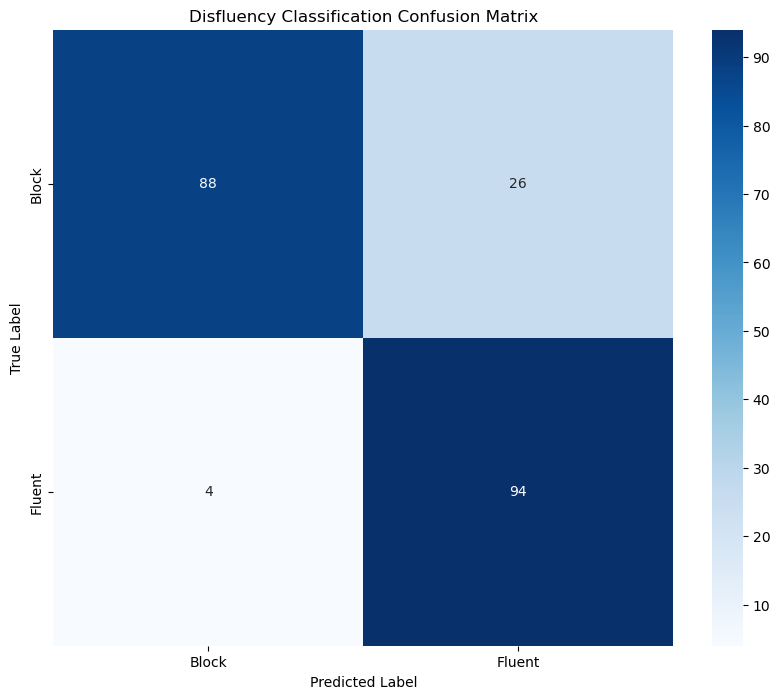


Detailed Classification Report:
              precision    recall  f1-score   support

       Block       0.96      0.77      0.85       114
      Fluent       0.78      0.96      0.86        98

    accuracy                           0.86       212
   macro avg       0.87      0.87      0.86       212
weighted avg       0.88      0.86      0.86       212



In [ ]:
cm = confusion_matrix(all_labels, all_preds)

class_names = label_encoder.classes_

# plot
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Disfluency Classification Confusion Matrix')
plt.show()

# (Precision, Recall, F1)
print("\nDetailed Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

In [8]:
# Save the model
import torch
import joblib

# Save model state dict
torch.save(model.state_dict(), 'block_model.pt')
# Also save the label encoder
joblib.dump(label_encoder, 'block_label_encoder.pkl')
print(f"Model and label encoder saved successfully")

Model and label encoder saved successfully
